# Homework for Lab 3.6


### Glove embedding

In [1]:
import requests, os, zipfile
import numpy as np
data_path = '/tmp/glove'
glove_file = os.path.join(data_path, 'glove.6B.50d.txt')
!rm -rf $data_path
os.makedirs(data_path)
!wget -nv -t 0 --show-progress -O $glove_file 'https://cloud.tu-ilmenau.de/s/m558re2RpoW8X2s/download/glove.6B.50d.txt'
!sleep 1
def read_glove_vecs(glove_file):
    with open(glove_file, 'r') as f:
        words = set()
        word_to_vec_map = {}
        for line in f:
            line = line.strip().split()
            curr_word = line[0]
            words.add(curr_word)
            word_to_vec_map[curr_word] = np.array(line[1:], dtype=np.float64)
    return words, word_to_vec_map
words, word_to_vec_map = read_glove_vecs(glove_file)


/tmp/glove/glove.6B 100%[===================>] 163.41M  18.5MB/s    in 8.5s    
2026-06-04 01:30:43 URL:https://cloud.tu-ilmenau.de/public.php/dav/files/m558re2RpoW8X2s? [171350079/171350079] -> "/tmp/glove/glove.6B.50d.txt" [1]


## 3.6.1 Semantic Qualities in Word Embeddings


In [2]:
import numpy as np

def get_embedding(word):
    vec = word_to_vec_map.get(word, None)
    return vec


emb = get_embedding('computer')
print("number of words: ", len(words))
print("shape: ", np.array(emb).shape)
print("embedding vector of computer", emb)


number of words:  400000
shape:  (50,)
embedding vector of computer [ 0.079084 -0.81504   1.7901    0.91653   0.10797  -0.55628  -0.84427
 -1.4951    0.13418   0.63627   0.35146   0.25813  -0.55029   0.51056
  0.37409   0.12092  -1.6166    0.83653   0.14202  -0.52348   0.73453
  0.12207  -0.49079   0.32533   0.45306  -1.585    -0.63848  -1.0053
  0.10454  -0.42984   3.181    -0.62187   0.16819  -1.0139    0.064058
  0.57844  -0.4556    0.73783   0.37203  -0.57722   0.66441   0.055129
  0.037891  1.3275    0.30991   0.50697   1.2357    0.1274   -0.11434
  0.20709 ]


In [3]:
import torch

def cosine_similarity(vec1, vec2):
    """
    Computes the cosine similarity between two vectors.

    Args:
        vec1 (np.ndarray or torch.Tensor): The first vector.
        vec2 (np.ndarray or torch.Tensor): The second vector.

    Returns:
        float: The cosine similarity between vec1 and vec2.
    """
    # Ensure vectors are numpy arrays
    if isinstance(vec1, torch.Tensor):
        vec1 = vec1.cpu().numpy()
    if isinstance(vec2, torch.Tensor):
        vec2 = vec2.cpu().numpy()

    dot_product = np.dot(vec1, vec2)
    norm_vec1 = np.linalg.norm(vec1)
    norm_vec2 = np.linalg.norm(vec2)
    similarity = dot_product / (norm_vec1 * norm_vec2)

    return similarity

print("Cosine similarity between apple and banana: ", cosine_similarity(get_embedding('apple'), get_embedding('banana')))
print("Cosine similarity between apple and computer: ", cosine_similarity(get_embedding('apple'),get_embedding('computer')))
print("Cosine similarity between banana and computer: ", cosine_similarity(get_embedding('banana'),get_embedding('computer')))

Cosine similarity between apple and banana:  0.5607927919268959
Cosine similarity between apple and computer:  0.6402844483410007
Cosine similarity between banana and computer:  0.10689609749170265


In [4]:
def find_closest_word(word, n):
    # Get embedding vector of input word
    word_vector = get_embedding(word)

    # Compute similarities
    similarity =  [ cosine_similarity(get_embedding(w_emb), word_vector) for w_emb in words ]

    # Top-k words having largest similarity
    idxs = np.argsort( similarity )[::-1][1:n+1]
    words_list = list(words)
    closest_words = [words_list[i] for i in idxs]

    return closest_words

print(find_closest_word('computer', 5))

['computers', 'software', 'technology', 'electronic', 'internet']


In [5]:
def find_analogy(word_a, word_b, word_c):

    # Convert words to lower case
    word_a, word_b, word_c = word_a.lower(), word_b.lower(), word_c.lower()

    # Get the embedding vectors
    e_a = get_embedding(word_a)
    e_b = get_embedding(word_b)
    e_c = get_embedding(word_c)

    max_cosine_sim = -100
    words_list = list(word_to_vec_map.keys())
    # Loop over the whole word vector set
    for w_idx, w in enumerate((word_to_vec_map)):
        w_vec = word_to_vec_map[w]
        # To avoid best_word being one of the input words, pass on them.
        if w in [word_a, word_b, word_c]:
            continue

        # Compute cosine similarity between the vector (e_b - e_a) and the vector (w - e_c)
        ### START YOUR CODE HERE ###
        cosine_sim = cosine_similarity(e_b - e_a, w_vec - e_c)
        ### END YOUR CODE HERE ###

        if cosine_sim > max_cosine_sim:
            # Set new max similarity
            max_cosine_sim = cosine_sim
            # Select new best_word
            best_word_idx = w_idx
            print(cosine_sim, words_list[best_word_idx])

    return words_list[best_word_idx]

print(f"a king is to a man, what a queen is to a {find_analogy('king', 'man', 'queen')}")
print(f" Paris is to a France, what the Rome is to {find_analogy('Paris', 'France', 'Rome')}")
print(f" water is to boat, what space is to {find_analogy('water','boat', 'space')}")

0.3508478184697663 the
0.40889595786517224 ,
0.5716773692828828 a
0.6443401708412946 she
0.6575439418188052 her
0.8396770104782169 woman
a king is to a man, what a queen is to a woman
0.21245341488446123 the
0.2166938372250813 of
0.22863311011895773 to
0.23107266589747372 for
0.2430877406480192 that
0.29790812771488706 has
0.34323671249130683 over
0.4351666413603108 against
0.49894270161910204 united
0.5166751182995233 nations
0.535657075391899 africa
0.5681823830063294 republic
0.6751479308174202 italy
 Paris is to a France, what the Rome is to italy
-0.015949517156179524 the
0.013351422915255906 a
0.018468576823352408 "
0.08209206025637669 's
0.08267272533142273 his
0.14644095751477393 who
0.14747468152931786 first
0.18325687839695365 american
0.18573106984133092 third
0.2639984713527818 killed
0.26829685258271224 british
0.2720790490279063 car
0.316254480833036 japanese
0.40021771966768355 aircraft
0.4228756762786506 flight
0.4584176627526973 plane
0.4599173796713867 crew
0.49989186

In [6]:
def find_odd_one_out(word_list):

    word_list_lower = [word.lower() for word in word_list]

    embedding_list = [
        get_embedding(word)
        for word in word_list_lower
    ]

    n = len(word_list_lower)

    scores = []

    for i in range(n):

        sims = []

        for j in range(n):

            if i == j:
                continue

            sim = cosine_similarity(
                embedding_list[i],
                embedding_list[j]
            )

            sims.append(sim)

        scores.append(np.mean(sims))

    return word_list_lower[np.argmin(scores)]

words_with_odd = ['computer', 'laptop', 'car', 'software']
print(f"odd on in the list - computer, laptop, car, software: {find_odd_one_out(words_with_odd)} ")

odd on in the list - computer, laptop, car, software: car 


In [7]:
def find_closest_emb(vec_emb):
    # Compute similarities
    similarity = [cosine_similarity(get_embedding(w), vec_emb) for w in words]

    idx = np.argmax(similarity)

    return list(words)[idx]

def get_shifted_word(sementic_vector, word):
    word_emb = get_embedding(word.lower())
    shifted_vec = word_emb + 3*sementic_vector
    shifted_word = find_closest_emb(shifted_vec)
    return shifted_word

young_words = ['junior', 'baby', 'child', 'teen', 'boy', 'girl','young']
old_words = ['senior', 'elder', 'grandpa', 'man', 'woman', 'grandma', 'old']

young_center = np.mean(
    [get_embedding(w) for w in young_words],
    axis=0
)

old_center = np.mean(
    [get_embedding(w) for w in old_words],
    axis=0
)

age_semantic = old_center - young_center


test_list = ['baby', 'girl', 'boy', 'stone', 'student', 'birthday']
for word in test_list:  
    print(f"old correspondance for {str(word)}: ", get_shifted_word(age_semantic, word))


old correspondance for baby:  grandma
old correspondance for girl:  confidant


old correspondance for boy:  confidant
old correspondance for stone:  tomb
old correspondance for student:  shokhin
old correspondance for birthday:  humayun


we will try the same task on the semantic quality: temperature

In [8]:
cold_words = ['ice', 'cold', 'freezing', 'snow', 'artic', 'fresh','frost', 'winter']
hot_words = ['fire', 'dry', 'sun', 'heat', 'boiling', 'spicy', 'summer', 'warm']

cold_center = np.mean(
    [get_embedding(w) for w in cold_words],
    axis=0
)

hot_center = np.mean(
    [get_embedding(w) for w in hot_words],
    axis=0
)

temp_semantic = hot_center - cold_center


test_list = ['cold', 'snow', 'winter', 'freeze', 'chill']
for word in test_list:  
    print(f"old correspondance for {str(word)}: ", get_shifted_word(temp_semantic, word))

old correspondance for cold:  warm
old correspondance for snow:  warm
old correspondance for winter:  warm
old correspondance for freeze:  transfer
old correspondance for chill:  warm


## 3.6.2 Text Classification with GloVe Embeddings


Nous préparons le dataset AG News et utilisons GloVe pour initialiser une couche d'embedding.
Le vocabulaire est construit à partir des mots vus dans l'ensemble d'entraînement, et la matrice d'embeddings est remplie avec les vecteurs GloVe correspondants.
Nous entraînons ensuite deux modèles : un avec embedding fixe et un avec embedding entraînable.


In [9]:
import torch.nn as nn
import torch.optim as optim
from datasets import load_dataset
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

dataset = load_dataset("SetFit/ag_news")
print(dataset)
print("Train size:", len(dataset["train"]))
print("Test size:", len(dataset["test"]))

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 7600
    })
})
Train size: 120000
Test size: 7600


In [10]:
pad = "^"
word_to_idx = {pad: 0, "<UNK>": 1} # using UNK for unknowned word
for text in dataset["train"]["text"]:
    text = text.lower()
    for token in text.split():
        if token in word_to_vec_map and token not in word_to_idx:
            word_to_idx[token] = len(word_to_idx)

print("Vocabulary size from AG News train split:", len(word_to_idx))

embedding_dim = 50
embedding_matrix = np.zeros((len(word_to_idx), embedding_dim), dtype=np.float32)
for word, idx in word_to_idx.items():
    if word == pad:
        continue
    if word == "<UNK>":
        embedding_matrix[idx] = np.zeros(embedding_dim, dtype=np.float32)
    else:
        embedding_matrix[idx] = word_to_vec_map[word].astype(np.float32)

max_len = 60

def text_to_indices(text):
    text = text.lower()
    tokens = text.split()
    ids = [word_to_idx.get(token, word_to_idx["<UNK>"]) for token in tokens]
    if len(ids) >= max_len:
        return ids[:max_len]
    return ids + [word_to_idx[pad]] * (max_len - len(ids))




Vocabulary size from AG News train split: 59394


#### Dataset

In [11]:
def build_dataset(split_name):
    texts = [text_to_indices(text) for text in dataset[split_name]["text"]]
    labels = dataset[split_name]["label"]
    return TensorDataset(torch.tensor(texts, dtype=torch.long),
                         torch.tensor(labels, dtype=torch.long))

train_dataset = build_dataset("train")
test_dataset = build_dataset("test")

batch_size = 256
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

print("Example sequence:", train_dataset[0][0][:20])
print("Example label:", train_dataset[0][1].item())

Example sequence: tensor([ 2,  3,  4,  5,  6,  7,  8,  9,  1, 10, 11,  1,  2,  1,  1, 12,  1, 13,
        14, 15])
Example label: 2


In [12]:
class NewsClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_classes, embedding_weights, num_layers = 1, drop_rate = 0.2, trainable_embedding=True):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.embedding.weight = nn.Parameter(torch.from_numpy(embedding_weights))
        self.embedding.weight.requires_grad = trainable_embedding # using a flage for training and fixed embedding
        self.lstm = nn.LSTM(embedding_dim, hidden_size, num_layers, batch_first=True)
        self.dropout = nn.Dropout(drop_rate)
        self.output = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        _, (hidden, _) = self.lstm(x)
        hidden = hidden[-1]
        hidden = self.dropout(hidden)
        return self.output(hidden)

def train_model(model, dataloader, optimizer, loss_fn, epochs=10):

    history = {"train_loss": [], "train_acc": []}

    model.to(device)

    for epoch in range(epochs):

        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for text_batch, label_batch in dataloader:

            text_batch = text_batch.to(device)
            label_batch = label_batch.to(device)
            logits = model(text_batch)
            loss = loss_fn(logits, label_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * text_batch.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == label_batch).sum().item()
            total += label_batch.size(0)

        epoch_loss = running_loss / total
        epoch_acc = correct / total

        history["train_loss"].append(epoch_loss)
        history["train_acc"].append(epoch_acc)

        print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")
    return history


def plot_history(history_fixed, history_trainable):
    plt.figure(figsize=(10, 5))
    plt.plot(history_fixed["train_loss"], label="Fixed embedding")
    plt.plot(history_trainable["train_loss"], label="Trainable embedding")
    plt.title("Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()


Fixed 

Epoch 1/10 | Loss: 1.1216 | Acc: 0.4471
Epoch 2/10 | Loss: 0.5488 | Acc: 0.7901
Epoch 3/10 | Loss: 0.4268 | Acc: 0.8594
Epoch 4/10 | Loss: 0.3860 | Acc: 0.8707
Epoch 5/10 | Loss: 0.3689 | Acc: 0.8762
Epoch 6/10 | Loss: 0.3566 | Acc: 0.8779
Epoch 7/10 | Loss: 0.3468 | Acc: 0.8805
Epoch 8/10 | Loss: 0.3394 | Acc: 0.8831
Epoch 9/10 | Loss: 0.3333 | Acc: 0.8847
Epoch 10/10 | Loss: 0.3280 | Acc: 0.8860
Trainable 

Epoch 1/10 | Loss: 1.1448 | Acc: 0.4225
Epoch 2/10 | Loss: 0.5200 | Acc: 0.8122
Epoch 3/10 | Loss: 0.4020 | Acc: 0.8657
Epoch 4/10 | Loss: 0.3652 | Acc: 0.8790
Epoch 5/10 | Loss: 0.3447 | Acc: 0.8851
Epoch 6/10 | Loss: 0.3254 | Acc: 0.8903
Epoch 7/10 | Loss: 0.3137 | Acc: 0.8947
Epoch 8/10 | Loss: 0.3000 | Acc: 0.8994
Epoch 9/10 | Loss: 0.2893 | Acc: 0.9031
Epoch 10/10 | Loss: 0.2797 | Acc: 0.9054


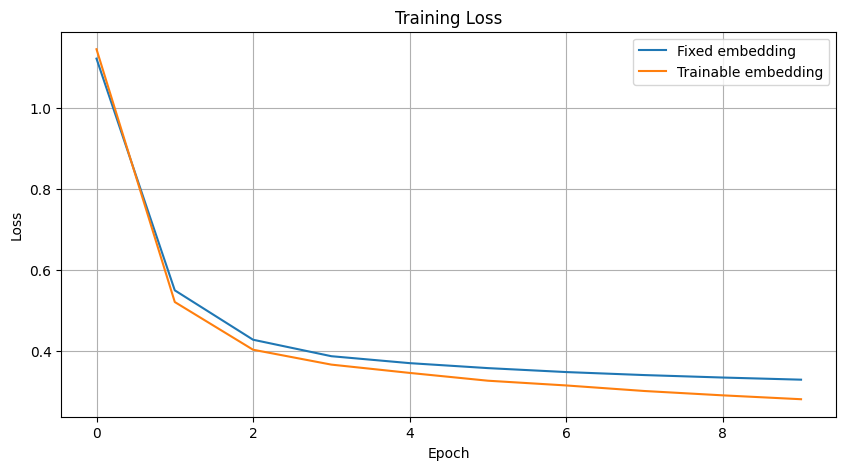

In [13]:
vocab_size = len(word_to_idx)
hidden_size = 128
num_classes = 4

fixed_model = NewsClassifier(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    hidden_size=hidden_size,
    num_classes=num_classes,
    embedding_weights=embedding_matrix,
    num_layers=1,
    trainable_embedding=False
).to(device)

trainable_model = NewsClassifier(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    hidden_size=hidden_size,
    num_classes=num_classes,
    embedding_weights=embedding_matrix,
    num_layers=1,
    trainable_embedding=True
).to(device)

loss_fn = nn.CrossEntropyLoss()
fixed_optimizer = optim.Adam(fixed_model.parameters(), lr=0.0001)
trainable_optimizer = optim.Adam(trainable_model.parameters(), lr=0.0001)

# Fixed embedding
print("Fixed \n")
history_fixed = train_model(fixed_model, train_loader, fixed_optimizer, loss_fn, epochs=10)

# trainable embedding
print("Trainable \n")
history_trainable = train_model(trainable_model, train_loader, trainable_optimizer, loss_fn, epochs=10)

plot_history(history_fixed, history_trainable)



#### Eval

In [14]:
def evaluate_model(model, dataloader, loss_fn):
    model.eval()
    model.to(device)
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for text_batch, label_batch in dataloader:
            text_batch = text_batch.to(device)
            label_batch = label_batch.to(device)
            logits = model(text_batch)
            loss = loss_fn(logits, label_batch)
            running_loss += loss.item() * text_batch.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == label_batch).sum().item()
            total += label_batch.size(0)
    return running_loss / total, correct / total

In [15]:
fixed_loss, fixed_acc = evaluate_model(fixed_model, test_loader, loss_fn)
trainable_loss, trainable_acc = evaluate_model(trainable_model, test_loader, loss_fn)

print(f"Fixed embedding test accuracy: {fixed_acc:.4f}")
print(f"Trainable embedding test accuracy: {trainable_acc:.4f}")

Fixed embedding test accuracy: 0.8841
Trainable embedding test accuracy: 0.9007


#### Results ?

Trainable model performs better with average accuracy up to 90% while the fixed model has an accuracy up to 0.88% (execution time = same)

## 3.6.3 IMDB Sentiment Classification

In [89]:
from datasets import load_dataset

dataset = load_dataset("stanfordnlp/imdb")

In [90]:
from collections import Counter

print(dataset)

# nb sample/split
for split in dataset:
    print(split, len(dataset[split]))

# positive and negative distribution
for split in dataset:
    print(split, Counter(dataset[split]["label"]))
    
# examples
print("POSITIVE EXAMPLES:\n")
for ex in dataset["train"]:
    if ex["label"] == 1:
        print(ex["text"][:300])
        break

print("NEGATIVE EXAMPLES:\n")
for ex in dataset["train"]:
    if ex["label"] == 0:
        print(ex["text"])
        break

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})
train 25000
test 25000
unsupervised 50000
train Counter({0: 12500, 1: 12500})
test Counter({0: 12500, 1: 12500})
unsupervised Counter({-1: 50000})
POSITIVE EXAMPLES:

Zentropa has much in common with The Third Man, another noir-like film set among the rubble of postwar Europe. Like TTM, there is much inventive camera work. There is an innocent American who gets emotionally involved with a woman he doesn't really understand, and whose naivety is all the more strik
NEGATIVE EXAMPLES:

I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this

Here: 
    train Counter({0: 12500, 1: 12500})
    test Counter({0: 12500, 1: 12500})
Indicates that the classification is binary: 0 ir 1 so num_class = 2

In [91]:
train_val = dataset["train"].train_test_split(test_size=0.2, seed=42)

train_dataset = train_val["train"]
val_dataset = train_val["test"]

test_dataset = dataset["test"]

#### Pre-processing

In [92]:
pad = "^"
word_to_idx = {pad: 0, "<UNK>": 1}

for text in train_dataset["text"]:
    text = text.lower()
    for token in text.split():
        if token in word_to_vec_map and token not in word_to_idx:
            word_to_idx[token] = len(word_to_idx)

print("Vocab size:", len(word_to_idx))

# embedding matrix
embedding_dim = 50
embedding_matrix = np.zeros((len(word_to_idx), embedding_dim), dtype=np.float32)

for word, idx in word_to_idx.items():
    if word == pad:
        continue
    if word == "<UNK>":
        embedding_matrix[idx] = np.zeros(embedding_dim)
    else:
        embedding_matrix[idx] = word_to_vec_map[word]


# text2indice

max_len = 60

def text_to_indices(text):
    text = text.lower()
    tokens = text.split()

    ids = [word_to_idx.get(t, word_to_idx["<UNK>"]) for t in tokens]

    if len(ids) >= max_len:
        return ids[:max_len]

    return ids + [word_to_idx[pad]] * (max_len - len(ids)) # cut sentences to same length

Vocab size: 53428


#### Dataset

In [93]:
def build_dataset(split_name):
    texts = [text_to_indices(t) for t in split_name["text"]]
    labels = split_name["label"]

    return TensorDataset(
        torch.tensor(texts, dtype=torch.long),
        torch.tensor(labels, dtype=torch.long)
    )

train_data = build_dataset(train_dataset)
val_data   = build_dataset(val_dataset)
test_data  = build_dataset(test_dataset)

batch_size = 512

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size)
test_loader = DataLoader(test_data, batch_size=batch_size)

print(len(train_data), len(val_data), len(test_data))

20000 5000 25000


### Model

In [94]:
class BiDiModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_classes, embedding_weights, num_layers = 1, drop_rate = 0.4, trainable_embedding=True):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.embedding.weight = nn.Parameter(torch.from_numpy(embedding_weights).float())
        self.embedding.weight.requires_grad = trainable_embedding # using a flage for training and fixed embedding
        
        self.lstm1 = nn.LSTM(embedding_dim, hidden_size, num_layers, batch_first=True, bidirectional=True)
        # expl: forward = hidden_size  backward = hidden_size => concatenate = 2*hidden_size
        self.lstm2= nn.LSTM(hidden_size*2, hidden_size, num_layers, batch_first=True, bidirectional=True)
        
        self.dropout = nn.Dropout(drop_rate)
        self.output = nn.Linear(hidden_size*2, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        x, _ = self.lstm1(x)
        x, (h_n, _) = self.lstm2(x)  
        
        forward = h_n[-2]
        backward = h_n[-1]
        
        x = torch.cat((forward, backward), dim=1)
        x = self.dropout(x)

        return self.output(x)

In [95]:
def train_model(model, dataloader, val_loader, optimizer, loss_fn, epochs=10):

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    model.to(device)

    for epoch in range(epochs):
        
        # training
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for text_batch, label_batch in dataloader:

            text_batch = text_batch.to(device)
            label_batch = label_batch.to(device)

            logits = model(text_batch)
            loss = loss_fn(logits, label_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * text_batch.size(0)
            preds = logits.argmax(dim=1)

            correct += (preds == label_batch).sum().item()
            total += label_batch.size(0)

        epoch_loss = running_loss / total
        epoch_acc = correct / total

        history["train_loss"].append(epoch_loss)
        history["train_acc"].append(epoch_acc)


        # validation
        model.eval()
        val_loss_sum = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for text_batch, label_batch in val_loader:

                text_batch = text_batch.to(device)
                label_batch = label_batch.to(device)

                logits = model(text_batch)
                loss = loss_fn(logits, label_batch)

                val_loss_sum += loss.item() * text_batch.size(0)
                preds = logits.argmax(dim=1)

                val_correct += (preds == label_batch).sum().item()
                val_total += label_batch.size(0)

        val_loss = val_loss_sum / val_total
        val_acc = val_correct / val_total

        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
        )

    return history

In [96]:
vocab_size = len(word_to_idx)
hidden_size = 64
num_classes = 2
trainable_model = BiDiModel(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    hidden_size=hidden_size,
    num_classes=num_classes,
    embedding_weights=embedding_matrix,
    num_layers=1,
    drop_rate = 0.4,
    trainable_embedding=True
).to(device)

loss_fn = nn.CrossEntropyLoss()
trainable_optimizer = optim.Adam(trainable_model.parameters(), lr=0.001)
history_trainable = train_model(trainable_model, train_loader, val_loader, trainable_optimizer, loss_fn, epochs=20)




Epoch 1/20 | Train Loss: 0.6744 | Train Acc: 0.5726 | Val Loss: 0.6150 | Val Acc: 0.6692
Epoch 2/20 | Train Loss: 0.5884 | Train Acc: 0.6928 | Val Loss: 0.6002 | Val Acc: 0.6806
Epoch 3/20 | Train Loss: 0.5422 | Train Acc: 0.7259 | Val Loss: 0.5319 | Val Acc: 0.7356
Epoch 4/20 | Train Loss: 0.4786 | Train Acc: 0.7739 | Val Loss: 0.5064 | Val Acc: 0.7506
Epoch 5/20 | Train Loss: 0.4308 | Train Acc: 0.8052 | Val Loss: 0.5030 | Val Acc: 0.7550
Epoch 6/20 | Train Loss: 0.3799 | Train Acc: 0.8337 | Val Loss: 0.5444 | Val Acc: 0.7546
Epoch 7/20 | Train Loss: 0.3373 | Train Acc: 0.8580 | Val Loss: 0.5020 | Val Acc: 0.7694
Epoch 8/20 | Train Loss: 0.2870 | Train Acc: 0.8837 | Val Loss: 0.5087 | Val Acc: 0.7778
Epoch 9/20 | Train Loss: 0.2392 | Train Acc: 0.9077 | Val Loss: 0.6121 | Val Acc: 0.7618
Epoch 10/20 | Train Loss: 0.1879 | Train Acc: 0.9294 | Val Loss: 0.6575 | Val Acc: 0.7604
Epoch 11/20 | Train Loss: 0.1521 | Train Acc: 0.9450 | Val Loss: 0.7276 | Val Acc: 0.7636
Epoch 12/20 | Train

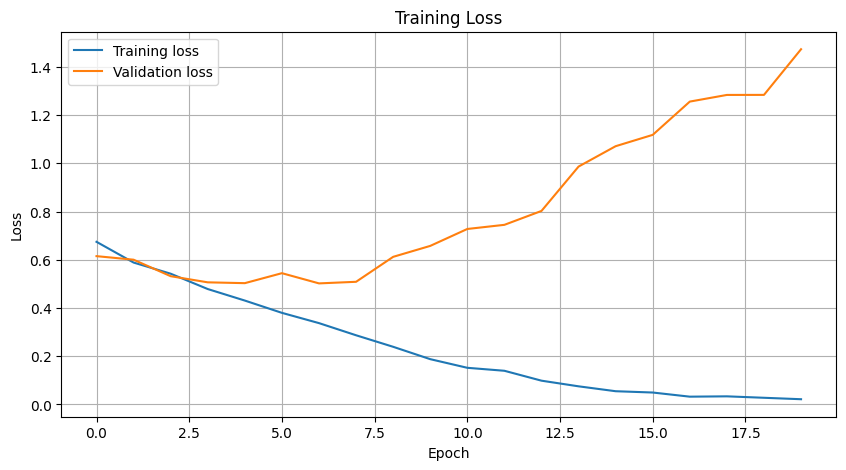

In [97]:
def plot_history(history_trainable):
    plt.figure(figsize=(10, 5))
    plt.plot(history_trainable["train_loss"], label="Training loss")
    plt.plot(history_trainable["val_loss"], label="Validation loss")
    plt.title("Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_history(history_trainable)


#### Eval

In [98]:
trainable_loss, trainable_acc = evaluate_model(trainable_model, test_loader, loss_fn)
print(f"Accuracy: {trainable_acc}")

Accuracy: 0.72008
